In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

In [2]:
def plot_slope_field(range_lims, func_expr, num_points=25):
    """
    Generates a normalized quiver plot (slope field) for a given 
    first-order ordinary differential equation.
    
    Parameters:
    range_lims (list): [min, max] values for both axes.
    func_expr (sympy expression): The derivative dy/dx expressed in x and y.
    num_points (int): Density of the grid.
    """
    
    # Define symbols for lambdification
    x, y = sym.symbols('x y')
    
    # Convert sympy expression to a numerical function for numpy arrays
    f_numeric = sym.lambdify((x, y), func_expr, 'numpy')
    
    # Create coordinate grid
    grid_space = np.linspace(range_lims[0], range_lims[1], num_points)
    X, Y = np.meshgrid(grid_space, grid_space)

    # Calculate components of the slope vectors
    # dx is constant (1), dy is the value of the differential equation
    dx = np.ones_like(X)
    dy = f_numeric(X, Y)
    
    # Normalize vectors so they all have the same visual length
    magnitude = np.sqrt(dx**2 + dy**2)
    u = dx / magnitude
    v = dy / magnitude

    # Plotting setup
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Configure axes to cross at the origin
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Set labels and title using LaTeX formatting
    ax.set_title(r'Slope Field: $\frac{dy}{dx} = f(x, y)$')
    ax.set_xlabel('$x$', loc='right')
    ax.set_ylabel('$y$', loc='top')
    ax.grid(alpha=0.3)

    # Plot the vectors
    # pivot='mid' ensures the line is centered on the grid point
    ax.quiver(X, Y, u, v, pivot='mid', color='royalblue', alpha=0.8)
    
    # Ensure the plot area is square
    ax.set_aspect('equal')
    
    plt.show()

def get_user_input():
    """
    Handles user interaction and safely parses mathematical strings.
    """
    x, y = sym.symbols('x y')
    
    try:
        raw_rng = input("Enter range (min, max): ").split(',')
        rng = [float(val.strip()) for val in raw_rng]
        
        raw_func = input("Enter dy/dx (e.g., 1/3 * (y-3)**3): ")
        # sympify is safer and more robust than eval() for math strings
        function = sym.sympify(raw_func)
        
        return rng, function
    except Exception as e:
        print(f"Error parsing input: {e}")
        return None, None


AttributeError: Unknown property loc

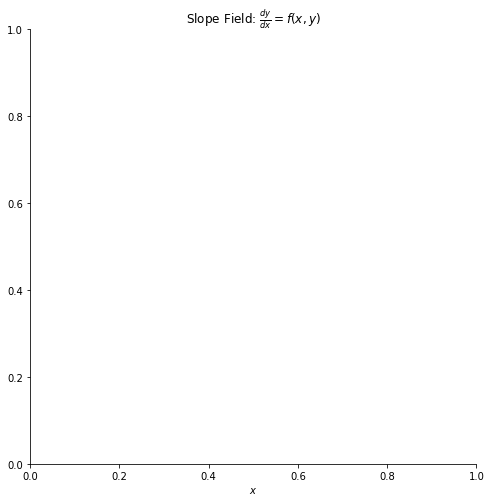

In [3]:
if __name__ == '__main__':
    # Define symbols for standalone execution
    x, y = sym.symbols('x y')
    
    # Example usage with the specific function provided
    example_range = [-2, 10]
    example_func = (1/3) * (y - 3)**3
    
    plot_slope_field(example_range, example_func)